# Домашнее задание: Построение RAG-системы с трансформерными декодерами

В этом домашнем задании вы закрепите знания о трансформерных декодерах и архитектуре Retrieval-Augmented Generation (RAG). Мы пройдем путь от простого полнотекстового поиска до продвинутого пайплайна с переранжированием и использованием LLM для генерации ответа.

## Практический бизнес-кейс: "ВикиПомощник" для контент-агентства

Крупное контент-агентство ежедневно создает сотни экспертных статей, аналитических отчетов и образовательных материалов. Редакторы агентства постоянно работают с огромным объемом энциклопедической информации. Сейчас процесс проверки фактов и поиска нужных деталей в справочниках занимает у них до 30% рабочего времени. Ручной поиск неэффективен, а использование публичных LLM без контекста часто приводит к галлюцинациям в статьях.

Руководство агентства поставило задачу разработать внутренний инструмент "ВикиПомощник". Это RAG-система, которая должна принимать вопрос редактора, мгновенно находить наиболее релевантные абзацы в проверенной базе знаний (русскоязычной Википедии) и формировать точный, лаконичный ответ на основе найденного контекста.

Ожидаемый результат внедрения ML-решения — сокращение времени на фактчекинг в 3 раза и полное устранение фактологических ошибок в выпускаемых материалах за счет опоры на доверенные источники.

## Рекомендации по выполнению в Google Colab

Для выполнения заданий, связанных с нейросетевыми моделями (BGE-M3, BGE-Reranker, Qwen3.5-9B), настоятельно рекомендуется использовать GPU.
1. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения`.
2. В поле `Аппаратный ускоритель` выберите `T4 GPU`.

**Решение проблемы нехватки памяти (CUDA Out of Memory):**
Если вы столкнулись с ошибкой `CUDA out of memory`, попробуйте следующие шаги:
- Уменьшите размер батча (например, с 32 до 16 или 8) при получении эмбеддингов.
- Ограничьте максимальную длину последовательности токенов (`max_length`).
- Перезапустите среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`).
- В коде можно использовать принудительную очистку кэша:
```python
import torch
import gc
torch.cuda.empty_cache()
gc.collect()
```

Не забудьте сохранить копию ноутбука на свой Google Drive перед началом работы (`Файл` -> `Сохранить копию на Google Диск`).

## Таблица распределения баллов

| Блок | Задание | Баллы |
|---|---|---|
| **Часть 1. Стандартное ДЗ** | | **50** |
| 1 | Загрузка и подготовка данных (SberQuAD) | 8 |
| 2 | Полнотекстовый поиск (BM25) | 10 |
| 3 | Семантический поиск (BGE-M3) | 12 |
| 4 | Оценка качества: BM25 vs Семантика | 8 |
| 5 | RAG с декодером (Qwen3.5-9B) | 7 |
| 6 | Оценка стоимости запросов | 5 |
| **Часть 2. Продвинутое ДЗ** | | **50** |
| 7 | Гибридный поиск (RRF) | 10 |
| 8 | Переранжирование (Cross-Encoder) | 12 |
| 9 | Полный пайплайн с переранжированием и LLM | 8 |
| 10 | Сравнительный анализ всех стратегий и замер скорости | 10 |
| 11 | Расширенная оценка стоимости запросов | 5 |
| 12 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [3]:
# Установка необходимых библиотек
!pip install -q datasets sentence-transformers faiss-cpu rank_bm25 openai tiktoken pandas matplotlib seaborn
print("Библиотеки установлены")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 84.1 MB/s eta 0:00:00:00:0100:01
Библиотеки установлены


## Блок 0: Формализация задачи

Прежде чем писать код, давайте формализуем нашу бизнес-задачу в терминах машинного обучения.
Бизнес-задача: Автоматизировать поиск фактов в базе знаний и формирование ответов на вопросы редакторов.
ML-задача: Построение пайплайна информационного поиска (Information Retrieval) и генерации текста (Text Generation).

Для оценки качества поиска мы будем использовать две метрики:
1. **Recall@K (Полнота)**: Доля запросов, для которых правильный ответ (ground truth) содержится хотя бы в одном из K найденных документов. Эта метрика критически важна для RAG, так как если нужной информации нет в контексте, LLM не сможет дать правильный ответ (или сгаллюцинирует).
2. **MRR@K (Mean Reciprocal Rank)**: Оценивает позицию первого релевантного документа в выдаче. Чем выше нужный документ, тем лучше, так как LLM обращают больше внимания на начало контекста (lost in the middle).

В RAG системах Recall обычно важнее Precision (точности), поскольку LLM способны отфильтровать нерелевантный шум в контексте, но не могут выдумать верный факт, если его вообще не передали в промпте.

---
# Часть 1. Стандартное ДЗ (50 баллов)


### Задание 1. Загрузка и подготовка данных (8 баллов)

Мы будем использовать датасет `kuznetsoffandrey/sberquad` — русскоязычный аналог популярного датасета SQuAD, собранный Сбером на основе статей Википедии.
Он содержит пары "контекст - вопрос - ответ".
В RAG системе уникальные тексты из поля `context` станут нашей базой знаний (корпусом документов), `question` — запросами пользователей, а `answers` мы будем использовать для автоматической оценки качества поиска.

**Что нужно сделать:**
1. Выполните предоставленный код загрузки датасета.
2. Напишите код для извлечения всех уникальных текстов из поля `context`. Это будет наш корпус документов. Сохраните их в список `corpus`.
3. Сформируйте словарь соответствия: `doc_id` -> `text`.
4. Подготовьте тестовую выборку: выберите 200 случайных вопросов из датасета. Для каждого вопроса сохраните сам текст вопроса и правильный ответ (из `answers['text'][0]`).
5. В комментариях кратко объясните, почему важно дедуплицировать контексты при создании базы знаний.


In [4]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import random
import json
import os
from pathlib import Path


# Загрузка датасета (используем только validation split для скорости)
print("Загрузка датасета SberQuAD...")
dataset = load_dataset("kuznetsoffandrey/sberquad", split="validation")
df = pd.DataFrame(dataset)
print(f"Загружено {len(df)} записей.")

# === ВАШ КОД ЗДЕСЬ ===
# Настройки для воспроизводимости и сохранения промежуточных результатов
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Определяем среду выполнения и настраиваем директорию проекта
if os.path.exists("/kaggle/working"):
    # Kaggle
    PROJECT_DIR = Path("/kaggle/working/Homework3")
else:
    try:
        # Google Colab
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_DIR = Path("/content/drive/MyDrive/LLM_NLP/Homework3")
    except (ImportError, NotImplementedError):
        # Локальный запуск
        PROJECT_DIR = Path("./Homework3")

STAGE_DIR = PROJECT_DIR / "stages"
FINAL_DIR = PROJECT_DIR / "final"

STAGE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR: {PROJECT_DIR}")

# 1. Извлеките уникальные контексты в список corpus
# Дедупликация важна, чтобы одинаковые тексты не занимали место в индексе повторно
# и не получали искусственное преимущество в поисковой выдаче.
corpus = df["context"].drop_duplicates().tolist()

# 2. Создайте словарь doc_id -> text (индексы от 0 до len(corpus)-1)
corpus_dict = {doc_id: text for doc_id, text in enumerate(corpus)}

# 3. Подготовьте 200 случайных тестовых вопросов
# Формат test_queries: список словарей [{'question': text, 'ground_truth': text}]
test_df = df.sample(n=200, random_state=RANDOM_STATE)
test_queries = [
    {
        "question": row["question"],
        "ground_truth": row["answers"]["text"][0],
    }
    for _, row in test_df.iterrows()
]

# Сохраняем подготовленные данные в google drivve
with open(os.path.join(STAGE_DIR, "corpus.json"), "w", encoding="utf-8") as f:
    json.dump(corpus, f, ensure_ascii=False)

with open(os.path.join(STAGE_DIR, "corpus_dict.json"), "w", encoding="utf-8") as f:
    json.dump(corpus_dict, f, ensure_ascii=False)

with open(os.path.join(STAGE_DIR, "test_queries.json"), "w", encoding="utf-8") as f:
    json.dump(test_queries, f, ensure_ascii=False, indent=2)


# === КОНЕЦ ВАШЕГО КОДА ===

print(f"Размер уникального корпуса: {len(corpus)} документов.")
print(f"Количество тестовых запросов: {len(test_queries)}")


Загрузка датасета SberQuAD...


README.md: 0.00B [00:00, ?B/s]

sberquad/train-00000-of-00001.parquet:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

sberquad/validation-00000-of-00001.parqu(…):   0%|          | 0.00/3.43M [00:00<?, ?B/s]

sberquad/test-00000-of-00001.parquet:   0%|          | 0.00/4.93M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

Загружено 5036 записей.
PROJECT_DIR: /kaggle/working/Homework3
Размер уникального корпуса: 3971 документов.
Количество тестовых запросов: 200


### Задание 2. Полнотекстовый поиск (BM25) (10 баллов)

BM25 (Best Matching 25) — это классический алгоритм полнотекстового поиска, основанный на TF-IDF.
Он учитывает частоту термина в документе (TF), редкость термина во всем корпусе (IDF) и нормализует результат по длине документа. BM25 отлично ищет по точным совпадениям ключевых слов.

**Что нужно сделать:**
1. Токенизируйте корпус (разбейте тексты на слова, например, по пробелам и приведя к нижнему регистру).
2. Инициализируйте объект `BM25Okapi` из библиотеки `rank_bm25`.
3. Реализуйте функцию `search_bm25(query, k=5)`, которая принимает запрос, токенизирует его и возвращает список ID топ-K наиболее релевантных документов.


In [5]:
from rank_bm25 import BM25Okapi

# === ВАШ КОД ЗДЕСЬ ===
# 1. Токенизация корпуса
tokenized_corpus = [text.lower().split() for text in corpus]

# 2. Инициализация BM25
bm25 = BM25Okapi(tokenized_corpus)

# 3. Функция поиска
def search_bm25(query, k=5):
    """
    Возвращает список из K идентификаторов (индексов в corpus) наиболее релевантных документов.
    """
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_doc_ids = np.argsort(scores)[::-1][:k]
    return top_doc_ids.tolist()

# Проверка работы
sample_query = "В каком году был основан Московский университет?"
print(f"Запрос: {sample_query}")
top_docs = search_bm25(sample_query, k=3)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===



Запрос: В каком году был основан Московский университет?
- В середине 1930-х годов иракское правительство решило создать ряд банков для того, чтобы сделать кре...
- В 2001 году Deutsche Bank открыл в Москве Центр Разработки ПО, который специализируется на создании ...
- Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитр...


### Задание 3. Семантический поиск (BGE-M3) (12 баллов)

Полнотекстовый поиск не понимает синонимов и опечаток. Эту проблему решает семантический поиск с использованием Bi-Encoder архитектуры.
Обе башни энкодера (для документа и для запроса) превращают текст в плотный вектор (эмбеддинг). Релевантность оценивается косинусным расстоянием между векторами.
Мы будем использовать модель `BAAI/bge-m3`, которая отлично работает с русским языком. Для быстрого поиска по векторам применим библиотеку FAISS.

**Что нужно сделать:**
1. Загрузите модель `BAAI/bge-m3` через `SentenceTransformer`.
2. Получите эмбеддинги для всего корпуса `corpus` (это может занять несколько минут на GPU).
3. Создайте FAISS индекс `IndexFlatIP` (внутреннее произведение, что эквивалентно косинусной близости для нормализованных векторов).
4. Добавьте нормализованные векторы корпуса в индекс.
5. Реализуйте функцию `search_semantic(query, k=5)`, которая векторизует запрос, нормализует вектор и ищет топ-K в FAISS.


In [6]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.10.0+cu128
True
Tesla T4


In [7]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import os

print("Загрузка модели BGE-M3...")
# Используем SentenceTransformer для удобства
embedder = SentenceTransformer('BAAI/bge-m3')

# === ВАШ КОД ЗДЕСЬ ===
# Пути для сохранения тяжелых промежуточных результатов
EMBEDDINGS_PATH = STAGE_DIR / "corpus_embeddings.npy"
FAISS_INDEX_PATH = os.path.join(STAGE_DIR, "faiss_bge_m3.index")

# 1. Получение эмбеддингов корпуса (используйте batch_size=16 или 32)
# Если эмбеддинги уже были посчитаны, загружаем их с Google Drive.
if os.path.exists(EMBEDDINGS_PATH):
    print("Загрузка сохраненных эмбеддингов корпуса...")
    corpus_embeddings = np.load(EMBEDDINGS_PATH)
else:
    print("Расчет эмбеддингов корпуса...")
    corpus_embeddings = embedder.encode(
        corpus,
        batch_size=16,
        show_progress_bar=True,
        convert_to_numpy=True,
    ).astype("float32")

    # 2. Нормализация векторов (важно для косинусного расстояния в FAISS)
    faiss.normalize_L2(corpus_embeddings)
    np.save(EMBEDDINGS_PATH, corpus_embeddings)

# На случай загрузки ранее сохраненных эмбеддингов приводим их к float32
# и повторно нормализуем: операция идемпотентна для уже нормализованных векторов.
corpus_embeddings = np.ascontiguousarray(corpus_embeddings, dtype="float32")
faiss.normalize_L2(corpus_embeddings)

# 3. Создание и заполнение FAISS индекса
dimension = embedder.get_embedding_dimension()
index = faiss.IndexFlatIP(dimension)
index.add(corpus_embeddings)
faiss.write_index(index, FAISS_INDEX_PATH)

# 4. Функция семантического поиска
def search_semantic(query, k=5):
    """
    Возвращает список из K идентификаторов наиболее релевантных документов.
    """
    query_embedding = embedder.encode(
        [query],
        convert_to_numpy=True,
    ).astype("float32")
    faiss.normalize_L2(query_embedding)

    _, doc_ids = index.search(query_embedding, k)
    return doc_ids[0].tolist()

# Проверка работы
top_docs = search_semantic(sample_query, k=3)
for doc_id in top_docs:
    print(f"- {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===



Загрузка модели BGE-M3...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Расчет эмбеддингов корпуса...


Batches:   0%|          | 0/249 [00:00<?, ?it/s]

- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факу...
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, котор...
- Некоторые авторы считают, что распространение университетов в средневековой Европе было связано с Ре...


### Задание 4. Оценка качества: BM25 vs Семантика (8 баллов)

Теперь давайте количественно сравним два подхода на нашей отложенной тестовой выборке из 200 вопросов.
Ниже предоставлена функция оценки. Она считает, что документ релевантен, если подстрока `ground_truth` (правильный ответ) содержится в тексте найденного документа.

**Что нужно сделать:**
1. Изучите код функции `evaluate_retriever`.
2. Запустите оценку для `search_bm25` и `search_semantic` с `k=5`.
3. Постройте столбчатую диаграмму (bar chart) для наглядного сравнения метрик Recall@5 и MRR@5 двух алгоритмов.


BM25: {'Recall@K': 0.785, 'MRR@K': 0.7486666666666667, 'Latency_ms': 10.153547525405884}
Semantic (BGE-M3): {'Recall@K': 0.915, 'MRR@K': 0.8510000000000001, 'Latency_ms': 24.66362476348877}


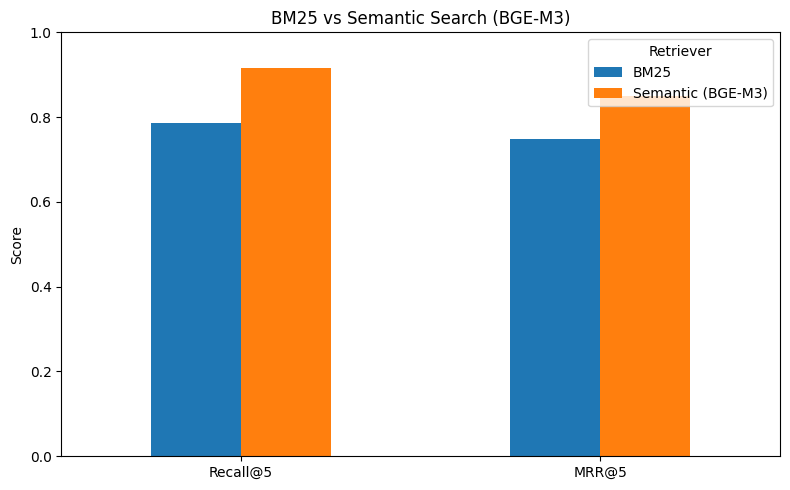

In [8]:
import time
import json
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_retriever(search_func, queries_data, corpus, k=5):
    recall_hits = 0
    mrr_sum = 0
    start_time = time.time()

    for item in queries_data:
        query = item['question']
        ground_truth = item['ground_truth'].lower()

        # Получаем топ-K doc_ids
        retrieved_ids = search_func(query, k=k)

        hit_rank = None
        for rank, doc_id in enumerate(retrieved_ids):
            doc_text = corpus[doc_id].lower()
            if ground_truth in doc_text:
                hit_rank = rank + 1
                break

        if hit_rank is not None:
            recall_hits += 1
            mrr_sum += 1.0 / hit_rank

    latency = time.time() - start_time

    recall = recall_hits / len(queries_data)
    mrr = mrr_sum / len(queries_data)
    avg_latency_ms = (latency / len(queries_data)) * 1000

    return {"Recall@K": recall, "MRR@K": mrr, "Latency_ms": avg_latency_ms}

# === ВАШ КОД ЗДЕСЬ ===
# 1. Запуск оценки
bm25_metrics = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
semantic_metrics = evaluate_retriever(search_semantic, test_queries, corpus, k=5)

print("BM25:", bm25_metrics)
print("Semantic (BGE-M3):", semantic_metrics)

# Сохраняем промежуточные метрики, чтобы не потерять результаты эксперимента.
retrieval_metrics = {
    "BM25": bm25_metrics,
    "Semantic (BGE-M3)": semantic_metrics,
}
with open(STAGE_DIR / "retrieval_metrics_tasks_4.json", "w", encoding="utf-8") as f:
    json.dump(retrieval_metrics, f, ensure_ascii=False, indent=2)

# 2. Визуализация результатов (matplotlib или seaborn)
metrics_df = pd.DataFrame({
    "BM25": [bm25_metrics["Recall@K"], bm25_metrics["MRR@K"]],
    "Semantic (BGE-M3)": [semantic_metrics["Recall@K"], semantic_metrics["MRR@K"]],
}, index=["Recall@5", "MRR@5"])

ax = metrics_df.plot(kind="bar", figsize=(8, 5), rot=0)
ax.set_title("BM25 vs Semantic Search (BGE-M3)")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Retriever")
plt.tight_layout()
plt.savefig(FINAL_DIR / "bm25_vs_semantic_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===




### Задание 5. RAG с декодером (Qwen3.5-9B) (7 баллов)

Поиск — это только половина RAG. Вторая половина — генерация ответа с помощью декодерной LLM.
Мы будем использовать модель `Qwen/Qwen3.5-9B-Instruct`. Вы можете вызывать ее через API (например, бесплатный OpenRouter) или загрузить локально, если позволяет видеопамять.

**Что нужно сделать:**
1. Реализуйте функцию `generate_answer(query, context_docs)`, которая формирует промпт (инструкция + контексты + вопрос) и вызывает LLM для получения ответа.
2. Напишите обертку `rag_pipeline(query, search_func, k=3)`, которая сначала ищет документы, а затем генерирует ответ.
3. Протестируйте ваш пайплайн на 3-5 любых вопросах (можно придумать свои), используя семантический поиск. Выведите вопрос, найденный контекст и ответ LLM.


In [9]:
import os
# Если используете OpenRouter API:
from openai import OpenAI
# client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key="YOUR_API_KEY")

# === ВАШ КОД ЗДЕСЬ ===
OPENROUTER_MODEL = "qwen/qwen3.5-9b"

def get_openrouter_api_key():
    """
    Получает OpenRouter API key из доступного окружения:
    1. Переменная окружения
    2. Kaggle Secrets
    3. Google Colab Secrets
    """
    # 1. Переменная окружения
    api_key = os.getenv("OPENROUTER_API_KEY")

    # 2. Kaggle Secrets
    if not api_key and os.path.exists("/kaggle/working"):
        try:
            from kaggle_secrets import UserSecretsClient

            api_key = UserSecretsClient().get_secret("OPENROUTER_API_KEY")
        except Exception:
            pass

    # 3. Google Colab Secrets
    if not api_key:
        try:
            from google.colab import userdata

            api_key = userdata.get("OPENROUTER_API_KEY")
        except Exception:
            pass

    if not api_key:
        raise ValueError(
            "Не найден OPENROUTER_API_KEY. "
            "Добавьте ключ в Kaggle Secrets, Google Colab Secrets "
            "или переменную окружения OPENROUTER_API_KEY."
        )

    return api_key

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=get_openrouter_api_key(),
)

def generate_answer(query, context_docs):
    """
    Формирует промпт и вызывает LLM.
    Возвращает текстовый ответ.
    """
    # prompt = f"Используй только следующий контекст для ответа на вопрос.\nКонтекст:\n{context_docs}\n\nВопрос: {query}\nОтвет:"
    context_text = "\n\n".join(
        f"Документ {i + 1}:\n{doc}" for i, doc in enumerate(context_docs)
    )

    chat_response = client.chat.completions.create(
        model=OPENROUTER_MODEL,
        messages=[
            {
                "role": "system",
                "content": (
                    "Ты — помощник по проверке фактов. Отвечай кратко и точно только на основании "
                    "предоставленного контекста. Если в контексте недостаточно информации для ответа, "
                    "прямо скажи об этом."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Контекст:\n{context_text}\n\n"
                    f"Вопрос: {query}\n"
                    "Ответ:"
                ),
            },
        ],
        temperature=0,
        max_tokens=300,
        extra_body={
            "reasoning": {
                "effort": "none" # Отключаем рассуждение
            }
        },
    )

    return chat_response.choices[0].message.content.strip()


def rag_pipeline(query, search_func, k=3):
    # 1. Поиск документов
    doc_ids = search_func(query, k=k)

    # 2. Объединение текстов документов в одну строку
    context_docs = [corpus[doc_id] for doc_id in doc_ids]

    # 3. Генерация ответа
    answer = generate_answer(query, context_docs)

    return {
        "question": query,
        "doc_ids": doc_ids,
        "context_docs": context_docs,
        "answer": answer,
    }

# Тестирование на 3-5 вопросах
# Используем вопросы из тестовой выборки, чтобы проверка была связана с текущим корпусом.
test_questions = [item["question"] for item in test_queries[:3]]

rag_test_results = []
for q in test_questions:
    result = rag_pipeline(q, search_semantic, k=3)
    rag_test_results.append(result)

    print("=" * 100)
    print(f"Вопрос: {result['question']}")
    print("\nНайденный контекст:")
    for i, doc in enumerate(result["context_docs"], start=1):
        print(f"\nДокумент {i}: {doc[:500]}...")
    print(f"\nОтвет Qwen: {result['answer']}")

# Сохраняем ответы RAG как промежуточный результат.
with open(STAGE_DIR / "rag_test_results.json", "w", encoding="utf-8") as f:
    json.dump(
        rag_test_results,
        f,
        ensure_ascii=False,
        indent=2,
    )

# === КОНЕЦ ВАШЕГО КОДА ===

Вопрос: UBS объявив о своей готовности к чему?

Найденный контекст:

Документ 1: В начале 2014 года стали известны планы UBS о расширении своей деятельности в Великобритании в области управления активами частных клиентов и увеличении сети своих подразделений Wealth Management, которые к тому моменту уже существовали в Лондоне, Бирмингеме, Эдинбурге, Лидсе, Манчестере и Ньюкасле. С этой целью планировалось открытие филиала UBS в юго-западной части страны. В начале 2017 года Аксель Вебер сообщил о планах UBS по сокращению численности своего персонала в Лондоне на тысячу сотруд...

Документ 2: UBS стремится в этой ситуации вести курс на минимизацию ущерба , объявив о своей готовности найти взаимоприемлемое решение . При этом банк ещё раз подчеркнул, что гражданский иск IRS является нарушением швейцарского права, в связи с чем данную проблему должны решать не суды, а правительства обеих стран в двустороннем формате. Кроме того, банк требует от американской стороны уточнить число счетов, ин

### Задание 6. Оценка стоимости запросов (5 баллов)

В коммерческой разработке важно понимать экономику продукта. Провайдеры API тарифицируют токены (входные и выходные).
Размер входного промпта напрямую зависит от количества передаваемых чанков (найденных документов) и их длины. Длина ответа контролируется системным промптом.

**Что нужно сделать:**
1. Используя библиотеку `tiktoken` (энкодер `cl100k_base` близок к большинству современных LLM), напишите функцию `estimate_cost(query, retrieved_docs, max_output_tokens)`.
2. Предположим тариф: $0.50 за 1M входных токенов и $1.50 за 1M выходных токенов.
3. Посчитайте среднюю стоимость 1000 запросов для трех сценариев:
   - k=1 (передаем 1 документ), короткий ответ (max 50 токенов)
   - k=3 (передаем 3 документа), средний ответ (max 150 токенов)
   - k=5 (передаем 5 документов), развернутый ответ (max 300 токенов)
4. В качестве запроса и документов используйте усредненные длины из вашего тестового набора.


In [10]:
import tiktoken

encoding = tiktoken.get_encoding("cl100k_base")

# === ВАШ КОД ЗДЕСЬ ===
INPUT_PRICE_PER_1M = 0.50
OUTPUT_PRICE_PER_1M = 1.50

# Используем цены заданные в условии, ниже актуальные цены в open router модели qwen/qwen3.5-9b.
# INPUT_PRICE_PER_1M = 0.10
# OUTPUT_PRICE_PER_1M = 0.15

def estimate_cost(query_text, docs_texts, max_output_tokens):
    """
    Возвращает стоимость одного запроса в долларах.
    """
    context_text = "\n\n".join(
        f"Документ {i + 1}:\n{doc}" for i, doc in enumerate(docs_texts)
    )
    prompt = (
        "Ты — помощник по проверке фактов. Отвечай кратко и точно только на основании "
        "предоставленного контекста. Если в контексте недостаточно информации для ответа, "
        "прямо скажи об этом.\n\n"
        f"Контекст:\n{context_text}\n\nВопрос: {query_text}\nОтвет:"
    )

    input_tokens = len(encoding.encode(prompt))
    input_cost = input_tokens / 1_000_000 * INPUT_PRICE_PER_1M
    output_cost = max_output_tokens / 1_000_000 * OUTPUT_PRICE_PER_1M

    return input_cost + output_cost

# Расчет для 3 сценариев
# Один раз получаем top-5 документов для всех тестовых вопросов и переиспользуем
# результаты для k=1, k=3 и k=5.
retrieved_test_docs = []
for item in test_queries:
    doc_ids = search_semantic(item["question"], k=5)
    docs = [corpus[doc_id] for doc_id in doc_ids]
    retrieved_test_docs.append((item["question"], docs))

scenarios = [
    {"scenario": "k=1, short", "k": 1, "max_output_tokens": 50},
    {"scenario": "k=3, medium", "k": 3, "max_output_tokens": 150},
    {"scenario": "k=5, long", "k": 5, "max_output_tokens": 300},
]

cost_results = []
for scenario in scenarios:
    request_costs = [
        estimate_cost(
            query_text=query,
            docs_texts=docs[:scenario["k"]],
            max_output_tokens=scenario["max_output_tokens"],
        )
        for query, docs in retrieved_test_docs
    ]

    avg_cost_per_request = float(np.mean(request_costs))
    cost_1000_requests = avg_cost_per_request * 1000

    cost_results.append({
        "Scenario": scenario["scenario"],
        "K": scenario["k"],
        "Max output tokens": scenario["max_output_tokens"],
        "Avg cost per request, $": avg_cost_per_request,
        "Cost per 1000 requests, $": cost_1000_requests,
    })

cost_df = pd.DataFrame(cost_results)
display(cost_df)

cost_df.to_csv(FINAL_DIR / "cost_estimation_tasks_6.csv", index=False)

# === КОНЕЦ ВАШЕГО КОДА ===



,Scenario,K,Max output tokens,"Avg cost per request, $","Cost per 1000 requests, $"
0,"k=1, short",1,50,0.000310,0.310462
1,"k=3, medium",3,150,0.000833,0.833148
2,"k=5, long",5,300,0.001440,1.439850


---
# Часть 2. Продвинутое ДЗ (50 баллов)

В этой части мы улучшим качество поиска, объединив сильные стороны BM25 и семантики, а также добавим этап переранжирования (Reranking).


### Задание 7. Гибридный поиск (RRF) (10 баллов)

BM25 хорош для точных совпадений (имена, артикулы), а семантика — для понимания смысла. Гибридный поиск объединяет их выдачу.
Один из лучших способов объединения списков разной природы без настройки весов — Reciprocal Rank Fusion (RRF).
Формула RRF: $Score(d) = \sum_{r \in R} \frac{1}{k + rank_r(d)}$, где $rank_r(d)$ — позиция документа в выдаче конкретного ретривера, а $k$ — константа сглаживания (обычно 60).

**Что нужно сделать:**
1. Реализуйте функцию `search_hybrid(query, k=5, rrf_k=60)`.
2. Внутри функции сделайте запрос к `search_bm25` (получите топ-20) и к `search_semantic` (получите топ-20).
3. Примените формулу RRF для подсчета итоговых скоров документов.
4. Отсортируйте документы по убыванию RRF-скора и верните топ-K.


In [11]:
# === ВАШ КОД ЗДЕСЬ ===
def search_hybrid(query, k=5, rrf_k=60):
    """
    Выполняет гибридный поиск с использованием Reciprocal Rank Fusion (RRF).
    """
    # 1. Получаем top-20 документов от каждого ретривера
    bm25_results = search_bm25(query, k=20)
    semantic_results = search_semantic(query, k=20)

    # 2. Считаем RRF-score для каждого документа
    # Первый документ в каждом рейтинге имеет rank=1.
    rrf_scores = {}

    for rank, doc_id in enumerate(bm25_results, start=1):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank)

    for rank, doc_id in enumerate(semantic_results, start=1):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (rrf_k + rank)

    # 3. Сортируем документы по убыванию итогового RRF-score
    ranked_docs = sorted(
        rrf_scores.items(),
        key=lambda item: item[1],
        reverse=True,
    )

    # 4. Возвращаем top-K идентификаторов документов
    return [doc_id for doc_id, _ in ranked_docs[:k]]

# Проверка
hybrid_top_docs = search_hybrid(sample_query, k=3)
print(f"Запрос: {sample_query}")
for doc_id in hybrid_top_docs:
    print(f"- {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===



Запрос: В каком году был основан Московский университет?
- Наивысшего расцвета княжество достигло в конце XVI — начале XVII века. При архиепископах Вольфе Дитр...
- Московский народный банк, МНБ — банк, учреждённый в 1919 году в Лондоне, Великобритания, советскими ...
- В середине 1930-х годов иракское правительство решило создать ряд банков для того, чтобы сделать кре...


### Задание 8. Переранжирование (Cross-Encoder) (12 баллов)

Bi-Encoder (наш BGE-M3) быстр, так как векторы документов предвычисляются. Но он упускает тонкие взаимосвязи между запросом и документом.
Cross-Encoder принимает на вход пару (Запрос, Документ) одновременно и прогоняет их через все слои внимания трансформера. Это медленно, поэтому его применяют только к небольшому топу кандидатов (переранжирование).

Мы будем использовать `BAAI/bge-reranker-v2-m3`.

**Что нужно сделать:**
1. Загрузите модель cross-encoder (через `SentenceTransformer` или `CrossEncoder`).
2. Реализуйте функцию `search_with_reranking(query, k=5, top_n_initial=20)`.
3. Внутри: получите `top_n_initial` кандидатов через `search_hybrid`.
4. Сформируйте пары `(query, doc_text)` для всех кандидатов и передайте их в cross-encoder для получения скоров.
5. Отсортируйте кандидатов по скорам cross-encoder и верните итоговые топ-K.


In [12]:
from sentence_transformers import CrossEncoder

print("Загрузка модели Reranker...")
reranker = CrossEncoder('BAAI/bge-reranker-v2-m3')

# === ВАШ КОД ЗДЕСЬ ===
RERANK_BATCH_SIZE = 16

def search_with_reranking(query, k=5, top_n_initial=20):
    """
    Двухстадийный поиск: гибридный поиск -> Cross-Encoder reranking -> top-K.
    """
    # 1. Получаем кандидатов через гибридный поиск
    candidate_ids = search_hybrid(query, k=top_n_initial)

    # 2. Формируем пары (query, document) для Cross-Encoder
    pairs = [
        (query, corpus[doc_id])
        for doc_id in candidate_ids
    ]

    # 3. Получаем relevance scores батчами
    rerank_scores = reranker.predict(
        pairs,
        batch_size=RERANK_BATCH_SIZE,
        show_progress_bar=False,
    )

    # 4. Сортируем кандидатов по убыванию score и возвращаем top-K
    ranked_candidates = sorted(
        zip(candidate_ids, rerank_scores),
        key=lambda item: float(item[1]),
        reverse=True,
    )

    return [doc_id for doc_id, _ in ranked_candidates[:k]]

# Проверка
reranked_top_docs = search_with_reranking(sample_query, k=3)
print(f"Запрос: {sample_query}")
for doc_id in reranked_top_docs:
    print(f"- {corpus[doc_id][:100]}...")
# === КОНЕЦ ВАШЕГО КОДА ===


Загрузка модели Reranker...


config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Запрос: В каком году был основан Московский университет?
- С 1804 по 1835 год в составе Московского университета и других российских университетов работал факу...
- В 1687 году в Москве была организована первая высшая школа — Славяно-греко-латинская академия, котор...
- В России до революции 1917 г. понятие кафедры связывалось не столько с административным подразделени...


### Задание 9. Полный пайплайн с переранжированием и LLM (8 баллов)

Теперь у нас есть мощный поисковый движок. Давайте обновим наш генеративный пайплайн.

**Что нужно сделать:**
1. Создайте функцию `advanced_rag_pipeline(query)`, которая использует `search_with_reranking` (k=3) для поиска контекста и ту же LLM (Qwen3.5-9B) для генерации.
2. Протестируйте на тех же 3-5 вопросах, что и в Задании 5.
3. В комментариях кратко отметьте, изменилось ли качество или детализация ответов.


In [13]:
# === ВАШ КОД ЗДЕСЬ ===
def advanced_rag_pipeline(query):
    """
    Полный RAG-пайплайн: Hybrid Search + Reranker + Qwen.
    """
    # 1. Поиск и переранжирование документов
    doc_ids = search_with_reranking(query, k=3)

    # 2. Получение текстов найденных документов
    context_docs = [corpus[doc_id] for doc_id in doc_ids]

    # 3. Генерация ответа той же LLM, что и в базовом RAG
    answer = generate_answer(query, context_docs)

    return {
        "question": query,
        "doc_ids": doc_ids,
        "context_docs": context_docs,
        "answer": answer,
    }


# Тестирование на тех же вопросах, что и в Задании 5
advanced_rag_results = []

for i, q in enumerate(test_questions):
    result = advanced_rag_pipeline(q)
    advanced_rag_results.append(result)

    print("=" * 100)
    print(f"Вопрос: {result['question']}")

    # Для наглядности сравниваем ответ базового RAG и Advanced RAG.
    if i < len(rag_test_results):
        print(f"\nОтвет Baseline RAG: {rag_test_results[i]['answer']}")

    print(f"Ответ Advanced RAG: {result['answer']}")
    print("\nКонтекст Advanced RAG:")
    for j, doc in enumerate(result["context_docs"], start=1):
        print(f"\nДокумент {j}: {doc[:500]}...")

# По результатам сравнения качество в целом осталось на уровне, но reranker улучшил точность контекста.
# На вопрос про электрогитару Gibson Baseline RAG добавил лишнюю модель SG, тогда как Advanced RAG
# после переранжирования дал точный ответ Les Paul. Для двух остальных вопросов ответы не изменились.

# Сохраняем результаты Advanced RAG как промежуточный результат.
with open(STAGE_DIR / "advanced_rag_results.json", "w", encoding="utf-8") as f:
    json.dump(advanced_rag_results, f, ensure_ascii=False, indent=2)

# === КОНЕЦ ВАШЕГО КОДА ===


Вопрос: UBS объявив о своей готовности к чему?

Ответ Baseline RAG: UBS объявил о своей готовности найти взаимоприемлемое решение.
Ответ Advanced RAG: UBS объявил о своей готовности найти взаимоприемлемое решение.

Контекст Advanced RAG:

Документ 1: UBS стремится в этой ситуации вести курс на минимизацию ущерба , объявив о своей готовности найти взаимоприемлемое решение . При этом банк ещё раз подчеркнул, что гражданский иск IRS является нарушением швейцарского права, в связи с чем данную проблему должны решать не суды, а правительства обеих стран в двустороннем формате. Кроме того, банк требует от американской стороны уточнить число счетов, информацию по которым требуется предоставить, поскольку на данный момент многие их владельцы доброво...

Документ 2: В начале 2014 года стали известны планы UBS о расширении своей деятельности в Великобритании в области управления активами частных клиентов и увеличении сети своих подразделений Wealth Management, которые к тому моменту уже существо

### Задание 10. Сравнительный анализ всех стратегий и замер скорости (10 баллов)

Пришло время подвести итоги работы поисковых алгоритмов.

**Что нужно сделать:**
1. Запустите `evaluate_retriever` на тестовой выборке (200 вопросов) для всех 4 стратегий:
   - BM25
   - Semantic (BGE-M3)
   - Hybrid (RRF)
   - Hybrid + Reranking
2. Сведите результаты (Recall@5, MRR@5, Latency_ms) в единую таблицу (pandas DataFrame).
3. Постройте два графика:
   - Сравнение метрик качества (Recall и MRR).
   - Сравнение задержки (Latency) для разных методов.


,Recall@5,MRR@5,Latency_ms
Retriever,,,
BM25,0.785,0.7487,10.2260
Semantic (BGE-M3),0.915,0.8510,25.3407
Hybrid (RRF),0.925,0.8400,36.7399
Hybrid + Reranker,0.935,0.9300,1293.1745


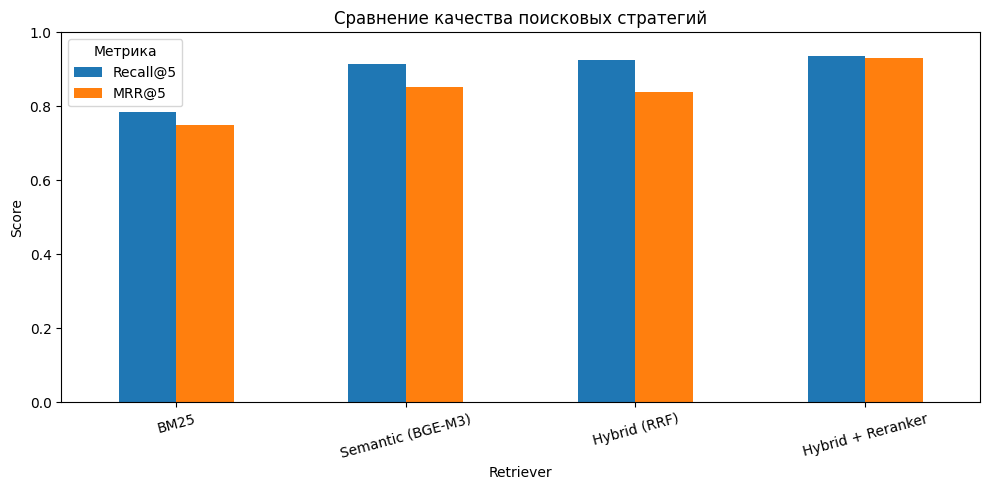

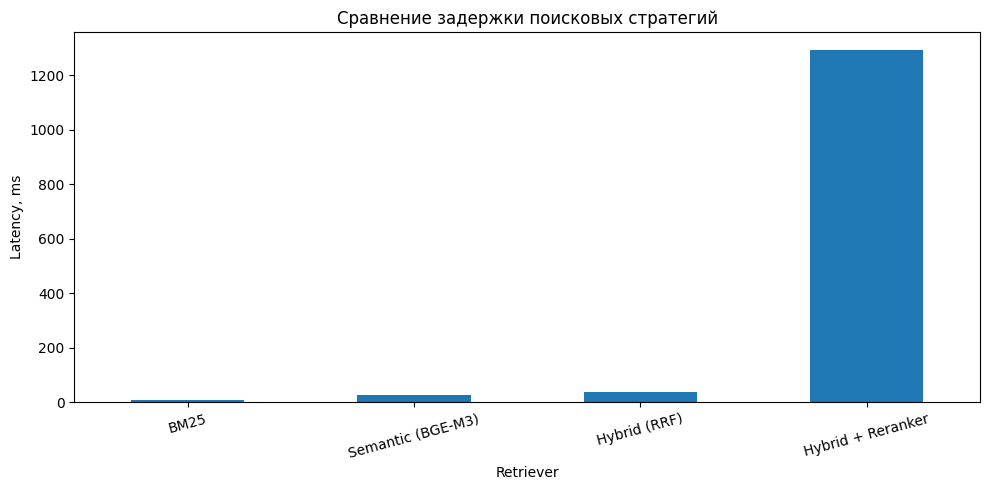

In [14]:
# === ВАШ КОД ЗДЕСЬ ===
# 1. Сбор метрик для всех четырех стратегий на одной тестовой выборке
bm25_metrics_all = evaluate_retriever(search_bm25, test_queries, corpus, k=5)
semantic_metrics_all = evaluate_retriever(search_semantic, test_queries, corpus, k=5)
hybrid_metrics = evaluate_retriever(search_hybrid, test_queries, corpus, k=5)
rerank_metrics = evaluate_retriever(search_with_reranking, test_queries, corpus, k=5)

# 2. Создание DataFrame и вывод таблицы
comparison_df = pd.DataFrame.from_dict(
    {
        "BM25": bm25_metrics_all,
        "Semantic (BGE-M3)": semantic_metrics_all,
        "Hybrid (RRF)": hybrid_metrics,
        "Hybrid + Reranker": rerank_metrics,
    },
    orient="index",
)

comparison_df.index.name = "Retriever"
comparison_df = comparison_df.rename(
    columns={
        "Recall@K": "Recall@5",
        "MRR@K": "MRR@5",
    }
)

display(comparison_df.round(4))

# Сохраняем итоговую таблицу метрик.
comparison_df.to_csv(FINAL_DIR / "retrieval_comparison_tasks_10.csv", encoding="utf-8")

with open(STAGE_DIR / "retrieval_metrics_tasks_10.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "BM25": bm25_metrics_all,
            "Semantic (BGE-M3)": semantic_metrics_all,
            "Hybrid (RRF)": hybrid_metrics,
            "Hybrid + Reranker": rerank_metrics,
        },
        f,
        ensure_ascii=False,
        indent=2,
    )

# 3. Визуализация качества
quality_df = comparison_df[["Recall@5", "MRR@5"]]

ax = quality_df.plot(
    kind="bar",
    figsize=(10, 5),
    rot=15,
)
ax.set_title("Сравнение качества поисковых стратегий")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_xlabel("Retriever")
ax.legend(title="Метрика")
plt.tight_layout()
plt.savefig(FINAL_DIR / "retrieval_quality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Визуализация latency
ax = comparison_df["Latency_ms"].plot(
    kind="bar",
    figsize=(10, 5),
    rot=15,
)
ax.set_title("Сравнение задержки поисковых стратегий")
ax.set_ylabel("Latency, ms")
ax.set_xlabel("Retriever")
plt.tight_layout()
plt.savefig(FINAL_DIR / "retrieval_latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===


### Задание 11. Расширенная оценка стоимости запросов (5 баллов)

В продвинутом пайплайне мы используем переранжирование, что увеличивает время ответа, но как это влияет на стоимость LLM?
Само переранжирование (cross-encoder) работает локально и бесплатно. Значит, стоимость API LLM зависит только от финального K (количества документов, передаваемых в промпт).

**Что нужно сделать:**
1. Постройте график зависимости стоимости 1000 запросов от параметра K (от 1 до 10) при фиксированной длине ответа (например, 150 токенов).
2. Используйте функцию `estimate_cost` из Задания 6. Усредните длину документа по корпусу для расчетов.


Средняя длина документа: 356 токенов
Средняя длина запроса: 29 токенов


,K,"Cost per 1000 requests, $"
0,1,0.461
1,2,0.642
2,3,0.823
3,4,1.004
4,5,1.185
5,6,1.366
6,7,1.547
7,8,1.728
8,9,1.909
9,10,2.090


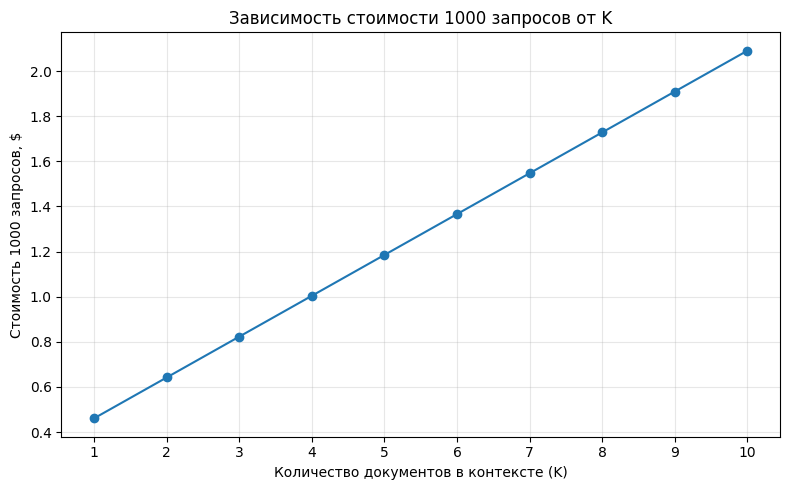

In [15]:
# === ВАШ КОД ЗДЕСЬ ===
# Фиксированная длина ответа 
FIXED_OUTPUT_TOKENS = 150

# Усредняем длину документа по всему корпусу в токенах.
corpus_token_lengths = [len(encoding.encode(doc)) for doc in corpus]
avg_doc_tokens = int(round(np.mean(corpus_token_lengths)))

# Для запроса используем среднюю длину вопросов из тестовой выборки.
query_token_lengths = [len(encoding.encode(item["question"])) for item in test_queries]
avg_query_tokens = int(round(np.mean(query_token_lengths)))

print(f"Средняя длина документа: {avg_doc_tokens} токенов")
print(f"Средняя длина запроса: {avg_query_tokens} токенов")


def make_text_with_token_count(token_count):
    """Создает технический текст примерно заданной длины в токенах cl100k_base."""
    base_text = ("текст " * (token_count * 2 + 10)).strip()
    token_ids = encoding.encode(base_text)[:token_count]
    return encoding.decode(token_ids)


# Синтетические тексты нужны только для передачи усредненных длин в estimate_cost.
avg_query_text = make_text_with_token_count(avg_query_tokens)
avg_doc_text = make_text_with_token_count(avg_doc_tokens)

# Считаем стоимость 1000 запросов для K от 1 до 10.
k_values = list(range(1, 11))
cost_per_1000 = []

for k in k_values:
    docs = [avg_doc_text] * k
    cost_one_request = estimate_cost(
        query_text=avg_query_text,
        docs_texts=docs,
        max_output_tokens=FIXED_OUTPUT_TOKENS,
    )
    cost_per_1000.append(cost_one_request * 1000)

cost_k_df = pd.DataFrame({
    "K": k_values,
    "Cost per 1000 requests, $": cost_per_1000,
})

display(cost_k_df)

# График зависимости стоимости от K
plt.figure(figsize=(8, 5))
plt.plot(
    cost_k_df["K"],
    cost_k_df["Cost per 1000 requests, $"],
    marker="o",
)
plt.title("Зависимость стоимости 1000 запросов от K")
plt.xlabel("Количество документов в контексте (K)")
plt.ylabel("Стоимость 1000 запросов, $")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FINAL_DIR / "cost_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

# Сохраняем результаты расчета.
cost_k_df.to_csv(FINAL_DIR / "cost_vs_k_tasks_11.csv", index=False)

# === КОНЕЦ ВАШЕГО КОДА ===


### Задание 12. Итоговые выводы (5 баллов)

Поздравляем с завершением практической части! Теперь проанализируйте полученные результаты.

**Что нужно сделать:**
Напишите развернутый вывод (3-4 абзаца) в markdown-ячейке ниже. Ответьте на вопросы:
1. Какой метод поиска показал лучшее качество на данном датасете и почему?
2. Оправдано ли использование тяжелого Reranker-а с точки зрения баланса качество/скорость (latency)? В каких бизнес-кейсах вы бы его рекомендовали, а в каких — отключили?
3. Как размер контекста (параметр K) влияет на баланс между качеством ответов LLM и стоимостью эксплуатации системы? Какое значение K вы бы выбрали для "ВикиПомощника"?

---
По качеству поиска лучший результат показал **Hybrid + Reranker**: Recall@5 = **0.935**, MRR@5 = **0.930**. Особенно заметен рост MRR по сравнению с BGE-M3 (0.851), то есть после переранжирования релевантный документ чаще оказывается на первых позициях. При этом чистый Hybrid RRF дал Recall@5 = 0.925, но MRR@5 = 0.840, поэтому простое объединение BM25 и семантического поиска не всегда улучшает порядок документов. BGE-M3 без reranker-а остаётся сильным базовым вариантом: Recall@5 = 0.915 и MRR@5 = 0.851.

Использование reranker-а оправдано, когда качество ответа важнее скорости: например, в фактчекинге, аналитике или внутренних корпоративных системах, где ошибка в контексте критична. Его latency составила около **1293 мс** против **25 мс** у BGE-M3, поэтому для интерактивного сервиса с большим потоком запросов такой рост задержки может быть слишком дорогим. В таких случаях я бы использовал BGE-M3 или Hybrid без reranker-а, а reranker включал только для сложных или высокорисковых запросов.

Размер контекста K напрямую увеличивает стоимость: при фиксированном ответе в 150 токенов стоимость 1000 запросов выросла с `$0.461 при K=1` до `$2.09 при K=10`. При этом слишком маленький K повышает риск не передать LLM нужный документ, а слишком большой добавляет нерелевантный контекст и увеличивает стоимость без гарантии улучшения ответа. Для «ВикиПомощника» я бы выбрал **K=3**: в наших экспериментах этого достаточно для RAG, а стоимость остаётся умеренной — около **$0.823 за 1000 запросов** по тарифам из задания. При необходимости более высокой точности можно использовать Hybrid + Reranker и передавать в LLM только top-3 документов после переранжирования.



## Критерии оценки
- **Работоспособность кода:** Код выполняется без ошибок, пайплайны поиска и генерации функционируют корректно.
- **Корректность алгоритмов:** Верная реализация RRF, правильное использование FAISS и Cross-Encoder.
- **Качество визуализации:** Графики читаемы, имеют оси и легенду, таблица метрик наглядна.
- **Глубина анализа:** Выводы в задании 12 логичны, опираются на полученные цифры и бизнес-контекст.
- **Оформление:** Код структурирован, присутствуют комментарии на русском языке, соблюден академический стиль.
